# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [191]:
import numpy as np


A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [192]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

print(A@e_1)
print(A@e_2)
print(A@e_3)

[1 4 7]
[2 5 8]
[3 6 9]


Due to our definition of matrix multiplication, where the 1 is in each vetor indicates which column of A we are selecting, as you would be multiplying each element in the other columns by 0, meaning you are only adding 1 times the element in the respective column of A, and 0 for each other column to get each element in the resulting matrix.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [107]:
u = np.ones(3)
print(A@u)

[ 6. 15. 24.]


Using a similar principle, the resulting matrix would represent the sums of each column in A. This is because each element in each column is added exactly one time.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [108]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])
A@x

array([-2,  4, 11])

When I multiply an identity matric by any vector, it will always result in just repeating the vector. When you translate this process to the definition of a matrix multuplication, we see that each instance of the vector is only summed exactly once, and only in the column it exists for. This means that each element in the vector is added by 0 for each other row, showing why the resulting vector is the original vector.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [151]:
A_1 = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x_1 = np.array([-2,4,11])
print(A_1@x_1)
A = np.array([ [1,0,0],
              [0,0,1],
              [0,1,0]])
x = np.array([-2,4,11])
print(A@x)

[11 -2  4]
[-2 11  4]


As you can see, the place in which the ones are placed in the matrix change the order in which the elements from the original vector appear in the resulting vector. The pattern, which can be derived from the definition of the derivative is that if you take the place of each 1, so for A_1, there are ones at (1,3), (2,1), and (3,2), the first place (row) indicates the order in the resulting vector, and the second place (column) indicates which element of the original vector goes in that place.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [152]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)
print(A@e_1)
print(A@e_2)
print(A@e_3)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]
[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


If A is a markov transition matrix, then each vector e indicates a potential initial state for the system, meaning that the 3 resulting vectors indicate the probabilites that outcome 1,2 or 3 happens depending on each inital state.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [ ]:
def matrix_mult(A,e):
    return A@e

for i in range(5):
    e_1 = matrix_mult(A,e_1)
    print(e_1)
for i in range(5):
    e_2 = matrix_mult(A,e_2)
    print(e_2)
for i in range(5):
    e_3 = matrix_mult(A,e_3)
    print(e_3)


[0.50052958 0.02574731 0.47372311]
[0.34368862 0.20257047 0.45374091]
[0.30404142 0.26036337 0.43559521]
[0.29476439 0.27514859 0.43008701]
[0.29266551 0.27862515 0.42870935]
[0.24049286 0.39251588 0.36699127]
[0.28214379 0.29937825 0.41847795]
[0.29004438 0.28341002 0.42654561]
[0.29163968 0.2804039  0.42795643]
[0.29197422 0.27979983 0.42822595]
[0.18358131 0.37907577 0.43734292]
[0.26334088 0.31930609 0.41735304]
[0.28521895 0.29032145 0.4244596 ]
[0.29050361 0.28220175 0.42729464]
[0.29171646 0.2802254  0.42805814]
[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


In [162]:
print(e_1)
print(e_2)
print(e_3)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


The resulting vectors end up being about the same after 5 iterations. This means that regardless of initial condition, the matrix will eventually find a steady state of [0.29,0.28,0.43].

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [194]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

((.25 X 1 + 0.5 X 0),(0.75 X 1,0.5 X 0)) is what is occuring through the formula, meaning the first result should be (0.25,0.75)

In [195]:
init_condition = np.array([1,0])
p_1=T@init_condition
p_2=T@p_1
p_3=T@p_2
p_4=T@p_3
p_5=T@p_4
p_6=T@p_5
print(p_1)
print(p_2)
print(p_3)
print(p_4)
print(p_5)
print(p_6)

[0.25 0.75]
[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]


This is not a column of T, instead, the second result is giving the probabilities of the second iteration of whatever the initial condition was predicting. Essentially, it is forecasting the likelihoods of the outcomes of the second trial, given the initial condition. 4
As we can see, it begins to settle at around [0.4,0.6] very early on. It appears to settle after the third or fourth iteration, and then it begins returning the steady state vector.

In [196]:
init_condition = np.array([0,1])
p_1=T@init_condition
p_2=T@p_1
p_3=T@p_2
p_4=T@p_3
print(p_1)
print(p_2)
print(p_3)
print(p_4)

[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]


Even when changing the initial condition, it settles to the same value of [0.4,0.6].

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [199]:

weather = pd.read_csv('data/cville_weather.csv')

In [200]:
weather.head()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [201]:

print(weather.shape)


(411, 13)


In [202]:
missing_values = weather.isna()
print(missing_values.sum())

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64


In [203]:
weather['DATE']

0      2024-01-04
1      2024-01-07
2      2024-01-09
3      2024-01-10
4      2024-01-24
          ...    
406    2025-01-27
407    2025-01-28
408    2025-01-29
409    2025-01-30
410    2025-02-01
Name: DATE, Length: 411, dtype: object

There are a ton of missing values. Almost all of some columns are completely missing, as most of this isn't extremely relevant to this exercise, as the missing values we care about are not the N/A values, its the fact that many dates are missing. For a Markov chain to be accurate, we need consecutive data, meaning we need to clean this data to ensure we are only looking at consecutive information. So to ensure this in my calculations, if the next row in the data set is not the next day, I will not add it to my transition matrix.

In [205]:
weather['DATE'] = pd.to_datetime(weather['DATE'])
weather['rain'] = np.where(weather['PRCP'] > 0, 1, 0)

transition_matrix = np.zeros((2,2))
for i in range(1, len(weather)):
    today = weather.loc[i - 1, 'rain']
    tomorrow = weather.loc[i, 'rain']

    if (weather.loc[i, 'DATE'] - weather.loc[i - 1, 'DATE']).days != 1:
        continue

    if today == 0:
        if tomorrow == 0:
            transition_matrix[0,0] += 1
        else:
            transition_matrix[0,1] += 1
    else:
        if tomorrow == 0:
            transition_matrix[1,0] += 1
        else:
            transition_matrix[1,1] += 1


transition_matrix = np.divide(
    transition_matrix,
    transition_matrix.sum(axis=1, keepdims=True),
    out=np.zeros_like(transition_matrix),
    where=transition_matrix.sum(axis=1, keepdims=True) != 0
)



In [206]:
transition_matrix

array([[0.73333333, 0.26666667],
       [0.38211382, 0.61788618]])

Based on my transition matrix, if it rained yesterday, there appears to be about a 62% chance that it will rain again today. If it was clear yesterday, than there is still about a 27% chance that it is going to rain again today.

In [207]:
init_condition = np.array([1,0])
p_1 = init_condition @ transition_matrix
p_2 = p_1 @ transition_matrix
p_3 = p_2 @ transition_matrix
p_4 = p_3 @ transition_matrix
p_5 = p_4 @ transition_matrix
p_6 = p_5 @ transition_matrix
p_7 = p_6 @ transition_matrix
p_8 = p_7 @ transition_matrix
p_9 = p_8 @ transition_matrix
p_10 = p_9 @ transition_matrix

print(p_1)
print(p_2)
print(p_3)
print(p_4)
print(p_5)
print(p_6)
print(p_7)
print(p_8)
print(p_9)
print(p_10)

[0.73333333 0.26666667]
[0.6396748 0.3603252]
[0.60678009 0.39321991]
[0.59522683 0.40477317]
[0.5911691 0.4088309]
[0.58974394 0.41025606]
[0.5892434 0.4107566]
[0.5890676 0.4109324]
[0.58900586 0.41099414]
[0.58898417 0.41101583]


In [208]:
init_condition = np.array([0,1])
p_1 = init_condition @ transition_matrix
p_2 = p_1 @ transition_matrix
p_3 = p_2 @ transition_matrix
p_4 = p_3 @ transition_matrix
p_5 = p_4 @ transition_matrix
p_6 = p_5 @ transition_matrix
p_7 = p_6 @ transition_matrix
p_8 = p_7 @ transition_matrix
p_9 = p_8 @ transition_matrix
p_10 = p_9 @ transition_matrix

print(p_1)
print(p_2)
print(p_3)
print(p_4)
print(p_5)
print(p_6)
print(p_7)
print(p_8)
print(p_9)
print(p_10)

[0.38211382 0.61788618]
[0.51631965 0.48368035]
[0.56345536 0.43654464]
[0.58001034 0.41998966]
[0.58582477 0.41417523]
[0.58786691 0.41213309]
[0.58858415 0.41141585]
[0.58883606 0.41116394]
[0.58892453 0.41107547]
[0.58895561 0.41104439]


As you can see, regardless of the initial condition, both rainy and sunny days seem to converge around the 5th or 6th iteration of the markov chain. The steady state vector appears to be about [0.59,0.41]

C:\Users\josep\AppData\Local\Temp\ipykernel_30640\1471690606.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=weather, x='PRCP', hue='rain', common_norm=False ).set(title='KDE')


[Text(0.5, 1.0, 'KDE')]

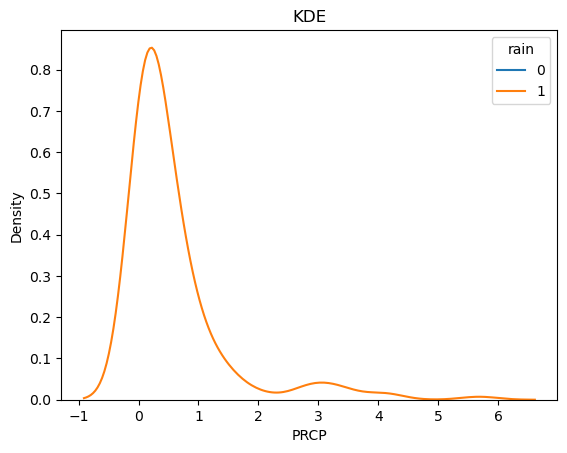

In [209]:
import seaborn as sns

sns.kdeplot(data=weather, x='PRCP', hue='rain', common_norm=False ).set(title='KDE')

To make this model better, there is first the issue of missing data. As many of the dates are missing, it means that the set that the transition matrix was built off of contains incomplete data, forcing me to remove dates. Since it seems reasonable to assume that this data is missing not at random, and the weather has an effect on whether the data is missing or not, (ie a lightning storm meaning people couldn't record a measurement that day), we are most likely missing some of the variation that would probably affect our markov chain. 

That being said, because whether or not it is going to rain is not only determined by previous day's weather, there is a certain cap on prediction strength that using a markov chain alone can provide. In order to make more accurate predictions, it may be helpful to collect more data, such as wind speed, temperature, etc. From there, we could build a parametric model that may explain more of the variation in rainy days.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [215]:
import pickle 
with open('data/taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

len(data)

1000

In [216]:

states = set(data[0])
for i in range(1, len(data)):
    new_trip = data[i]
    new_states = set(new_trip)
    states = states.union(new_states)

states=list(states)
states

['Midtown',
 'Liberty Island',
 'Roosevelt Island',
 'Washington Heights',
 'Morningside Heights',
 'West Village',
 'Little Italy',
 'Harlem',
 'Outside Manhattan',
 'Gramercy',
 'Chinatown',
 'Ellis Island',
 'Chelsea',
 'East Harlem',
 'SoHo',
 'Marble Hill',
 'East Village',
 'Lower East Side',
 "Randall's Island",
 'Battery Park City',
 'Civic Center',
 'Upper West Side',
 'Murray Hill',
 'Two Bridges',
 'Greenwich Village',
 'Stuyvesant Town',
 'NoHo',
 'Central Park',
 'Flatiron District',
 'Inwood',
 'Tribeca',
 "Hell's Kitchen",
 'Theater District',
 'Kips Bay',
 'Nolita',
 'Financial District',
 'Governors Island',
 'Upper East Side']

In [217]:
tr_counts = np.zeros((len(states),len(states)))


In [218]:
for trip in data:
    seq = np.array(trip)
    for t in range(1,len(seq)):
        # Current and next tokens:
        x_tm1 = seq[t-1] # previous state
        x_t = seq[t] # current state
        # Determine transition indices:
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        # Update transition counts:
        tr_counts[index_to, index_from] += 1

In [219]:
tr_counts

array([[1.389343e+06, 0.000000e+00, 1.219000e+03, ..., 3.411100e+04,
        0.000000e+00, 5.075020e+05],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        0.000000e+00, 0.000000e+00],
       [1.426000e+03, 0.000000e+00, 9.750000e+02, ..., 8.000000e+01,
        0.000000e+00, 9.320000e+02],
       ...,
       [4.084600e+04, 0.000000e+00, 4.300000e+01, ..., 1.361470e+05,
        1.000000e+00, 1.763500e+04],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        2.000000e+00, 0.000000e+00],
       [4.843950e+05, 0.000000e+00, 1.519000e+03, ..., 1.338000e+04,
        0.000000e+00, 1.283151e+06]], shape=(38, 38))

In [220]:
sums = tr_counts.sum(axis=0, keepdims=True)

In [221]:

tr_pr = np.divide(tr_counts, sums, 
                             out=np.zeros_like(tr_counts), 
                             where=sums!=0)

tr_df = pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)
print(tr_df)

                     Midtown  Liberty Island  Roosevelt Island  \
Midtown                 0.36             0.0              0.15   
Liberty Island          0.00             0.0              0.00   
Roosevelt Island        0.00             0.0              0.12   
Washington Heights      0.00             0.0              0.00   
Morningside Heights     0.00             0.0              0.00   
West Village            0.02             0.0              0.01   
Little Italy            0.00             0.0              0.00   
Harlem                  0.00             0.0              0.00   
Outside Manhattan       0.06             0.0              0.28   
Gramercy                0.02             1.0              0.01   
Chinatown               0.00             0.0              0.00   
Ellis Island            0.00             0.0              0.00   
Chelsea                 0.07             0.0              0.03   
East Harlem             0.01             0.0              0.01   
SoHo      

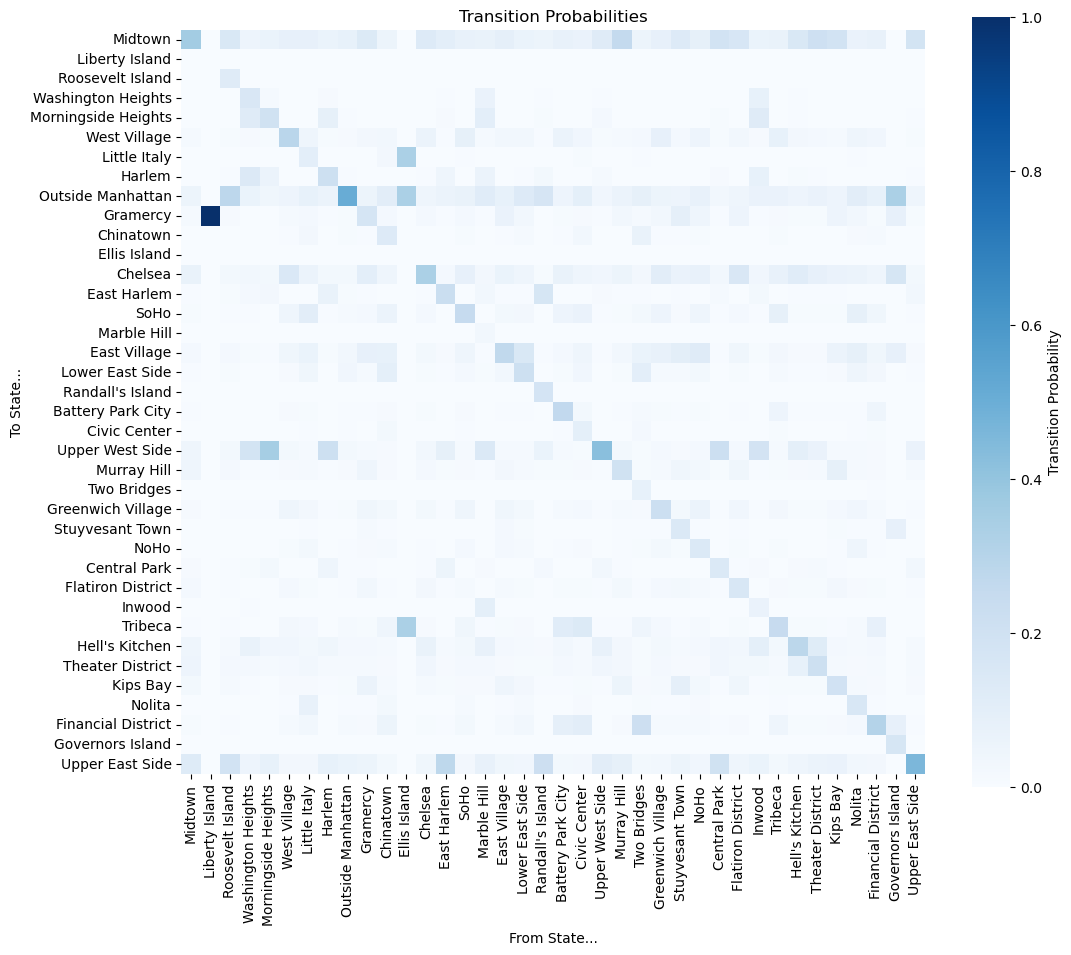

In [223]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(tr_pr, 
            cmap='Blues',    
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('From State...')
plt.ylabel('To State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Looking at the heat-map, it appears that the most common routes seem to be from one neighborhood to the same neighborhood. Obviously, we see some routes, like Liberty Island to Gramercy being extremely probable, however, it is only because there is only 1 route leaving Liberty Island (as it is an island), and it went to Gramercy.

Taxicabs are most likely 1 sequence as opposed to 2, because the driver does not decide where to go. Unlike Ubers, cab drivers are given the instructions on where to go after the rider enters the vehicle, and they have very little say over whether or not to take that job. Therefore, if we are measuring starting and ending location, than the previous rider has control over the next driver's starting location, but nothing beyond that, meaning that it is extremely unlikely that a rider will have any impact on a route two riders in the future. 

In [224]:
initial_state = "Hell's Kitchen"

state_index = states.index(initial_state) # Get the index of the initial state
print(f'Initial state: {initial_state}') 

n_sim = 11

simulation = [initial_state]
for t in range(n_sim-1): 
    pr_t = tr_pr[:,state_index] # Transition probabilities at this state
    state_index = np.random.choice(len(states), p=pr_t) # Choose new state index
    simulation.append(states[state_index]) # Append new state to simulation

print(simulation)

Initial state: Hell's Kitchen
["Hell's Kitchen", "Hell's Kitchen", "Hell's Kitchen", 'Gramercy', 'Murray Hill', 'Chelsea', 'SoHo', 'Chelsea', 'Chelsea', "Hell's Kitchen", 'Chelsea']


In [234]:
initial_state = np.random.choice(states)

state_index = states.index(initial_state) # Get the index of the initial state
print(f'Initial state: {initial_state}') 

n_sim = 1000

simulation = [initial_state]
for t in range(n_sim-1): 
    pr_t = tr_pr[:,state_index] # Transition probabilities at this state
    state_index = np.random.choice(len(states), p=pr_t) # Choose new state index
    simulation.append(states[state_index]) # Append new state to simulation

print(simulation[-5:])

pd.Series(simulation).value_counts()

Initial state: Nolita
['Upper West Side', 'Upper West Side', 'Midtown', 'Upper West Side', 'Harlem']


Midtown                164
Upper East Side        127
Outside Manhattan      101
Chelsea                 84
Upper West Side         65
Hell's Kitchen          51
West Village            44
East Village            43
Theater District        37
Financial District      28
Murray Hill             24
Gramercy                23
SoHo                    22
Lower East Side         20
Flatiron District       19
Kips Bay                18
Greenwich Village       17
Battery Park City       15
East Harlem             15
Tribeca                 14
Central Park            14
Harlem                  10
Morningside Heights     10
NoHo                     8
Washington Heights       8
Nolita                   6
Chinatown                4
Stuyvesant Town          3
Inwood                   3
Civic Center             2
Two Bridges              1
Name: count, dtype: int64

In [236]:
initial_state = np.random.choice(states)

state_index = states.index(initial_state) # Get the index of the initial state
print(f'Initial state: {initial_state}') 

n_sim = 1000

simulation = [initial_state]
for t in range(n_sim-1): 
    pr_t = tr_pr[:,state_index] # Transition probabilities at this state
    state_index = np.random.choice(len(states), p=pr_t) # Choose new state index
    simulation.append(states[state_index]) # Append new state to simulation

print(simulation[-5:])

pd.Series(simulation).value_counts()

Initial state: SoHo
['Chelsea', 'West Village', 'Chelsea', "Hell's Kitchen", "Hell's Kitchen"]


Midtown                181
Upper East Side        117
Outside Manhattan       91
Upper West Side         85
Chelsea                 85
Hell's Kitchen          48
East Village            45
West Village            38
Theater District        35
Murray Hill             33
Greenwich Village       33
SoHo                    28
Gramercy                25
Lower East Side         22
Central Park            20
Kips Bay                16
Tribeca                 15
East Harlem             15
Flatiron District       13
Financial District      11
Battery Park City        9
NoHo                     9
Harlem                   6
Stuyvesant Town          5
Nolita                   4
Chinatown                4
Washington Heights       2
Civic Center             2
Morningside Heights      1
Little Italy             1
Inwood                   1
Name: count, dtype: int64

After starting at a random spot, it appears that the majority of the time, cabbies spend their time either in Midtown, Outside Manhattan, or on the upper east side, which we can see seems to be consistent regardless of where the cabbie starts.